In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

files = list(DATA_DIR.glob("*.xlsx"))

for f in files:
    print(f.name)
    

ASAR_blood_banking_district_dataset-1.xlsx
ASAR_blood_banking_district_dataset.xlsx
ASAR_blood_banking_state_dataset-1.xlsx
ASAR_blood_banking_state_dataset.xlsx


In [2]:
for f in files:
    xls = pd.ExcelFile(f)
    print(f"\n{f.name}")
    print("Sheets:", xls.sheet_names)

    for sheet in xls.sheet_names:
        df = pd.read_excel(f, sheet_name=sheet)
        print(f"  {sheet}: {df.shape}")


ASAR_blood_banking_district_dataset-1.xlsx
Sheets: ['Description', 'District Level Data', 'District Level Dictionary']
  Description: (6, 2)
  District Level Data: (616, 39)
  District Level Dictionary: (39, 5)

ASAR_blood_banking_district_dataset.xlsx
Sheets: ['Description', 'District Level Data', 'District Level Dictionary']
  Description: (6, 2)
  District Level Data: (616, 39)
  District Level Dictionary: (39, 5)

ASAR_blood_banking_state_dataset-1.xlsx
Sheets: ['Description', 'State Level Data', 'State Level Dictionary']
  Description: (6, 2)
  State Level Data: (35, 304)
  State Level Dictionary: (302, 5)

ASAR_blood_banking_state_dataset.xlsx
Sheets: ['Description', 'State Level Data', 'State Level Dictionary']
  Description: (6, 2)
  State Level Data: (35, 304)
  State Level Dictionary: (302, 5)


In [3]:
district_file = DATA_DIR / "ASAR_blood_banking_district_dataset.xlsx"

district_df = pd.read_excel(
    district_file,
    sheet_name="District Level Data"
)

print("Shape:", district_df.shape)
display(district_df.head())

Shape: (616, 39)


,district_name,state_name,NACO_supported,Non_NACO,Total_Support,bb_availaibility,bb_own_public,bb_own_nfp,bb_own_priv,average_annual_naco,...,district_mean_assessment_score_nonnaco,district_category_35,district_category_35_70,district_category_70,district_naco_category_35,district_naco_category_35_70,district_naco_category_70,district_nonnaco_category_35,district_nonnaco_category_35_70,district_nonnaco_category_70
0,Tehri Garhwal,Uttarakhand,1,0.0,1,1.62,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chickballapur,Karnataka,1,NaN,1,0.80,1.0,NaN,NaN,7576.0,...,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Bidar,Karnataka,1,NaN,1,0.60,1.0,NaN,NaN,7067.0,...,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Haveri,Karnataka,1,NaN,1,0.60,1.0,NaN,NaN,2021.0,...,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Kodagu,Karnataka,1,NaN,1,1.80,1.0,NaN,NaN,1554.0,...,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [4]:
missing = district_df.isna().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(district_df) * 100).round(2)
})

display(missing_summary[missing_summary["missing_count"] > 0])


,missing_count,missing_percent
NACO_supported,3,0.49
Non_NACO,5,0.81
bb_own_public,6,0.97
bb_own_nfp,10,1.62
bb_own_priv,24,3.90
average_annual_naco,5,0.81
average_annual_nonnaco,7,1.14
district_voluntary_collection,1,0.16
district_replacement_collection,5,0.81
district_annual_collection,1,0.16


In [5]:
print("Duplicate rows:", district_df.duplicated().sum())

print("Districts:", district_df["district_name"].nunique())
print("States:", district_df["state_name"].nunique())

print("\nDuplicate district names:")
display(
    district_df[
        district_df.duplicated("district_name", keep=False)
    ][["district_name", "state_name"]].sort_values("district_name")
)

Duplicate rows: 0
Districts: 612
States: 35

Duplicate district names:


,district_name,state_name
171,Aurangabad,Maharashtra
536,Aurangabad,Bihar
20,Bilaspur,Chattisgarh
485,Bilaspur,Himachal Pradesh
325,Hamirpur,Himachal Pradesh
556,Hamirpur,Uttar Pradesh
484,Pratapgarh,Rajasthan
502,Pratapgarh,Uttar Pradesh


In [6]:
features = [
    "bb_availaibility",
    "district_annual_per100",
    "percentage_voluntary_district",
    "district_mean_assessment_score"
]

display(district_df[features].describe().T)

,count,mean,std,min,25%,50%,75%,max
bb_availaibility,616.0,2.809237,3.787730,0.0,0.90,1.8,3.300,49.29
district_annual_per100,615.0,0.988504,2.431409,0.0,0.20,0.5,1.100,51.24
percentage_voluntary_district,615.0,68.850569,29.824157,0.0,50.65,76.6,95.250,100.00
district_mean_assessment_score,615.0,56.254602,14.001259,0.0,52.00,59.0,64.685,80.87


In [7]:
display(
    district_df.nlargest(10, "bb_availaibility")
    [["district_name", "state_name", "bb_availaibility"]]
)

display(
    district_df.nlargest(10, "district_annual_per100")
    [["district_name", "state_name", "district_annual_per100"]]
)

,district_name,state_name,bb_availaibility
125,New Delhi,Delhi,49.29
585,Upper Siang,Arunachal Pradesh,28.30
427,Fazilka,Punjab,26.10
6,Mahe,Puducherry,23.90
581,Tawang,Arunachal Pradesh,20.00
582,Diu,Daman & Diu,19.20
239,Shamli,Uttar Pradesh,18.60
286,Yanam,Puducherry,18.00
529,Saiha,Mizoram,17.70
98,Hyderabad,Telangana,17.20


,district_name,state_name,district_annual_per100
125,New Delhi,Delhi,51.24
11,Central Delhi,Delhi,11.98
7,Kolkata,West Bengal,11.70
268,Shahdara,Delhi,10.39
67,Jaipur,Rajasthan,10.10
517,Fatehgarh Sahib,Punjab,9.50
427,Fazilka,Punjab,8.80
343,Chandigarh,Chandigarh,8.50
90,South Delhi,Delhi,6.89
98,Hyderabad,Telangana,6.22


In [8]:
display(
    district_df[features].corr().round(3)
)

,bb_availaibility,district_annual_per100,percentage_voluntary_district,district_mean_assessment_score
bb_availaibility,1.000,0.602,0.055,0.064
district_annual_per100,0.602,1.000,0.017,0.190
percentage_voluntary_district,0.055,0.017,1.000,0.392
district_mean_assessment_score,0.064,0.190,0.392,1.000


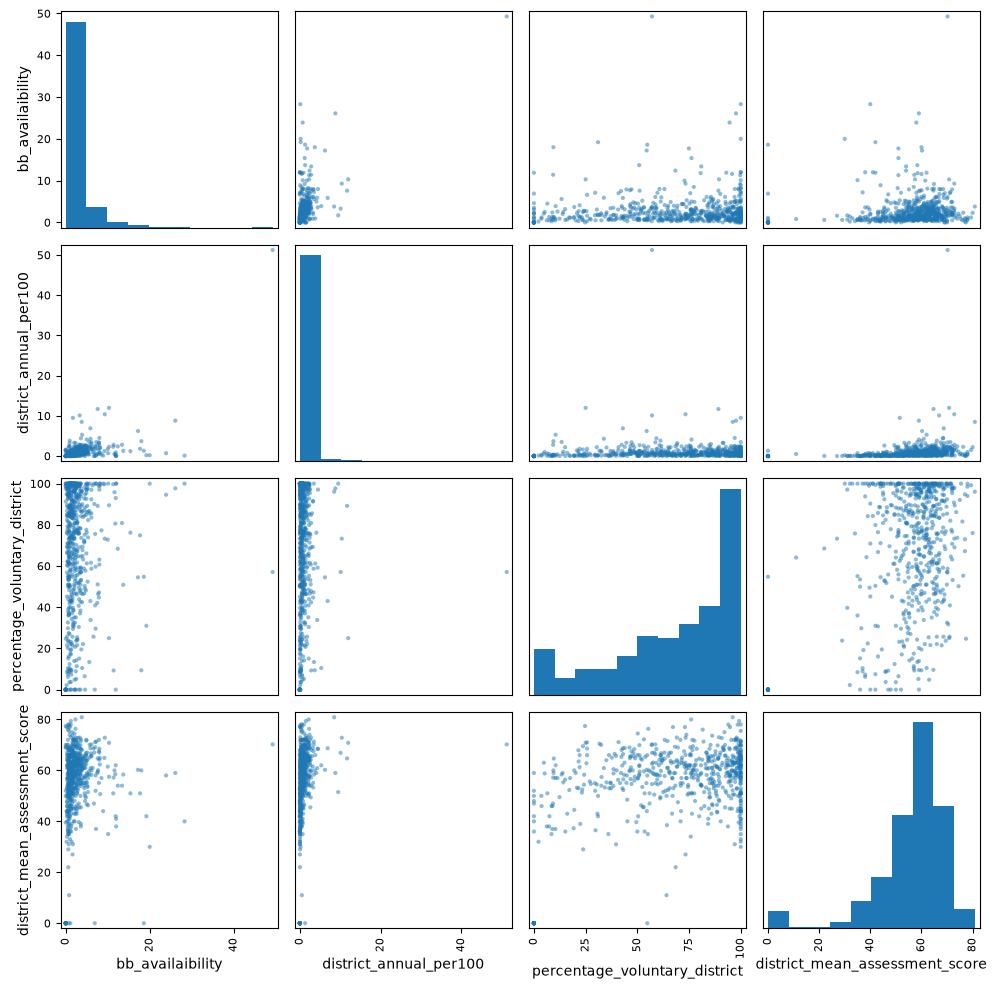

In [9]:
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(
    district_df[features],
    figsize=(10, 10),
    diagonal="hist"
)

plt.tight_layout()
plt.show()

In [10]:
district_df[
    ["bb_availaibility", "district_annual_per100", "percentage_voluntary_district"]
].skew()

bb_availaibility                  5.296912
district_annual_per100           15.149756
percentage_voluntary_district    -0.853481
dtype: float64

In [11]:
model_cols = [
    "district_name",
    "state_name",
    "bb_availaibility",
    "district_annual_per100",
    "percentage_voluntary_district",
    "district_mean_assessment_score"
]

model_df = district_df[model_cols].dropna().copy()

print("Rows:", len(model_df))
print("Dropped:", len(district_df) - len(model_df))

Rows: 615
Dropped: 1


In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = model_df[
    ["bb_availaibility",
     "district_annual_per100",
     "percentage_voluntary_district"]
].copy()

X["bb_availaibility"] = np.log1p(X["bb_availaibility"])
X["district_annual_per100"] = np.log1p(X["district_annual_per100"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)
print("Means:", X_scaled.mean(axis=0).round(3))
print("Std:", X_scaled.std(axis=0).round(3))

Shape: (615, 3)
Means: [0. 0. 0.]
Std: [1. 1. 1.]


In [13]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=21,
    metric="euclidean"
)

knn.fit(X_scaled)

distances, indices = knn.kneighbors(X_scaled)

print("Distance matrix:", distances.shape)
print("Index matrix:", indices.shape)

Distance matrix: (615, 21)
Index matrix: (615, 21)


In [14]:
# Remove each district itself from its peer list
peer_indices = indices[:, 1:]

# Calculate the average value of each feature among the 20 peers
peer_mean = np.array([
    X.iloc[peer_indices[i]].mean(axis=0)
    for i in range(len(X))
])

# Calculate district value minus peer average
gap = X.values - peer_mean

feature_names = [
    "bb_availaibility",
    "district_annual_per100",
    "percentage_voluntary_district"
]

gap_df = pd.DataFrame(
    gap,
    columns=[f"{f}_gap" for f in feature_names]
)

# Add district information
gap_df.insert(0, "district_name", model_df["district_name"].values)
gap_df.insert(1, "state_name", model_df["state_name"].values)

print("Gap table:", gap_df.shape)
display(gap_df.head(10))

Gap table: (615, 5)


,district_name,state_name,bb_availaibility_gap,district_annual_per100_gap,percentage_voluntary_district_gap
0,Chickballapur,Karnataka,-0.044705,0.014385,2.705
1,Bidar,Karnataka,-0.033570,0.063171,-0.665
2,Haveri,Karnataka,-0.023795,-0.025759,1.445
3,Kodagu,Karnataka,-0.024725,-0.058008,-4.555
4,Medak,Telangana,0.067965,-0.047796,2.130
5,Mahe,Puducherry,0.654335,-0.011538,6.415
6,Kolkata,West Bengal,0.132241,0.721234,18.875
7,Jalpaiguri,West Bengal,-0.257394,0.213514,-0.945
8,Vellore,Tamil Nadu,-0.054902,0.053967,-1.090
9,Sirsa,Haryana,-0.196249,0.082127,-2.040


In [15]:
# Convert the district-vs-peer differences into standardized gap scores
# using the standard deviation of each feature across districts.

feature_std = X.std(axis=0, ddof=0)

relative_gap = gap / feature_std

relative_gap_df = pd.DataFrame(
    relative_gap,
    columns=[
        "availability_gap_z",
        "collection_gap_z",
        "voluntary_gap_z"
    ]
)

relative_gap_df.insert(
    0, "district_name", model_df["district_name"].values
)
relative_gap_df.insert(
    1, "state_name", model_df["state_name"].values
)

display(relative_gap_df.head(10))

ValueError: Length of values (615) does not match length of index (3)

In [16]:
# Convert gap to a NumPy array to avoid pandas alignment issues
gap_array = np.asarray(gap)

# X is already standardized, so these are directly comparable
relative_gap = gap_array

relative_gap_df = pd.DataFrame(
    relative_gap,
    columns=[
        "availability_gap_z",
        "collection_gap_z",
        "voluntary_gap_z"
    ]
)

relative_gap_df.insert(
    0,
    "district_name",
    model_df["district_name"].values
)

relative_gap_df.insert(
    1,
    "state_name",
    model_df["state_name"].values
)

print("Shape:", relative_gap_df.shape)
display(relative_gap_df.head(10))

Shape: (615, 5)


,district_name,state_name,availability_gap_z,collection_gap_z,voluntary_gap_z
0,Chickballapur,Karnataka,-0.044705,0.014385,2.705
1,Bidar,Karnataka,-0.033570,0.063171,-0.665
2,Haveri,Karnataka,-0.023795,-0.025759,1.445
3,Kodagu,Karnataka,-0.024725,-0.058008,-4.555
4,Medak,Telangana,0.067965,-0.047796,2.130
5,Mahe,Puducherry,0.654335,-0.011538,6.415
6,Kolkata,West Bengal,0.132241,0.721234,18.875
7,Jalpaiguri,West Bengal,-0.257394,0.213514,-0.945
8,Vellore,Tamil Nadu,-0.054902,0.053967,-1.090
9,Sirsa,Haryana,-0.196249,0.082127,-2.040


In [17]:
# Calculate peer standard deviation for each district
peer_std = np.array([
    X.iloc[peer_indices[i]].std(axis=0, ddof=0).values
    for i in range(len(X))
])

# Avoid division by zero
peer_std = np.where(peer_std == 0, np.nan, peer_std)

# Standardized difference from peers
peer_z = gap_array / peer_std

peer_z_df = pd.DataFrame(
    peer_z,
    columns=[
        "availability_peer_z",
        "collection_peer_z",
        "voluntary_peer_z"
    ]
)

peer_z_df.insert(0, "district_name", model_df["district_name"].values)
peer_z_df.insert(1, "state_name", model_df["state_name"].values)

display(peer_z_df.head(10))

,district_name,state_name,availability_peer_z,collection_peer_z,voluntary_peer_z
0,Chickballapur,Karnataka,-0.353257,0.149093,0.773537
1,Bidar,Karnataka,-0.238750,0.522566,-0.098554
2,Haveri,Karnataka,-0.256357,-0.293012,0.602791
3,Kodagu,Karnataka,-0.162290,-0.563402,-0.633100
4,Medak,Telangana,0.579864,-0.493436,0.631237
5,Mahe,Puducherry,2.028914,-0.034087,0.420398
6,Kolkata,West Bengal,0.245494,1.743168,0.806548
7,Jalpaiguri,West Bengal,-1.294057,1.821175,-0.098861
8,Vellore,Tamil Nadu,-0.406042,0.570147,-0.141166
9,Sirsa,Haryana,-1.235114,0.516763,-0.155022


In [18]:
gap_columns = [
    "availability_peer_z",
    "collection_peer_z",
    "voluntary_peer_z"
]

# Most negative dimension
peer_z_df["primary_gap"] = peer_z_df[gap_columns].idxmin(axis=1)

# Convert technical names to readable labels
gap_labels = {
    "availability_peer_z": "Availability",
    "collection_peer_z": "Collection",
    "voluntary_peer_z": "Voluntary Donation"
}

peer_z_df["primary_gap"] = peer_z_df["primary_gap"].map(gap_labels)

# Strength of the primary gap
peer_z_df["primary_gap_z"] = peer_z_df[gap_columns].min(axis=1)

# Flag only substantial negative deviations
peer_z_df["significant_gap"] = peer_z_df["primary_gap_z"] <= -1.0

display(
    peer_z_df[
        ["district_name", "state_name",
         "primary_gap", "primary_gap_z",
         "significant_gap"]
    ].head(20)
)

,district_name,state_name,primary_gap,primary_gap_z,significant_gap
0,Chickballapur,Karnataka,Availability,-0.353257,False
1,Bidar,Karnataka,Availability,-0.238750,False
2,Haveri,Karnataka,Collection,-0.293012,False
3,Kodagu,Karnataka,Voluntary Donation,-0.633100,False
4,Medak,Telangana,Collection,-0.493436,False
5,Mahe,Puducherry,Collection,-0.034087,False
6,Kolkata,West Bengal,Availability,0.245494,False
7,Jalpaiguri,West Bengal,Availability,-1.294057,True
8,Vellore,Tamil Nadu,Availability,-0.406042,False
9,Sirsa,Haryana,Availability,-1.235114,True


In [19]:
# Global standard deviation in the transformed feature space
global_std = X.std(axis=0, ddof=0).values

# District vs peer-average, standardized using GLOBAL variability
global_relative_gap = gap_array / global_std

global_gap_df = pd.DataFrame(
    global_relative_gap,
    columns=[
        "availability_global_z",
        "collection_global_z",
        "voluntary_global_z"
    ]
)

global_gap_df["primary_gap_global"] = (
    global_gap_df[
        [
            "availability_global_z",
            "collection_global_z",
            "voluntary_global_z"
        ]
    ].idxmin(axis=1)
)

global_labels = {
    "availability_global_z": "Availability",
    "collection_global_z": "Collection",
    "voluntary_global_z": "Voluntary Donation"
}

global_gap_df["primary_gap_global"] = (
    global_gap_df["primary_gap_global"].map(global_labels)
)

# Compare the two methods
comparison = pd.DataFrame({
    "district_name": model_df["district_name"].values,
    "peer_method": peer_z_df["primary_gap"].values,
    "global_method": global_gap_df["primary_gap_global"].values
})

agreement = (
    comparison["peer_method"] ==
    comparison["global_method"]
).mean()

print(f"Method agreement: {agreement:.2%}")

display(comparison.head(20))

Method agreement: 96.59%


,district_name,peer_method,global_method
0,Chickballapur,Availability,Availability
1,Bidar,Availability,Availability
2,Haveri,Collection,Collection
3,Kodagu,Voluntary Donation,Voluntary Donation
4,Medak,Collection,Collection
5,Mahe,Collection,Collection
6,Kolkata,Availability,Availability
7,Jalpaiguri,Availability,Availability
8,Vellore,Availability,Availability
9,Sirsa,Availability,Availability


In [20]:
print(f"Method agreement: {agreement:.2%}")


Method agreement: 96.59%


In [21]:
from sklearn.neighbors import NearestNeighbors

k_values = [10, 20, 30]
k_results = {}

for k in k_values:

    knn_k = NearestNeighbors(
        n_neighbors=k + 1,
        metric="euclidean"
    )

    knn_k.fit(X_scaled)

    distances_k, indices_k = knn_k.kneighbors(X_scaled)

    # Remove the district itself
    peers_k = indices_k[:, 1:]

    # Peer mean
    peer_mean_k = np.array([
        X.iloc[peers_k[i]].mean(axis=0)
        for i in range(len(X))
    ])

    # District - peer mean
    gap_k = X.values - peer_mean_k

    # Use peer SD
    peer_std_k = np.array([
        X.iloc[peers_k[i]].std(axis=0, ddof=0).values
        for i in range(len(X))
    ])

    peer_std_k = np.where(peer_std_k == 0, np.nan, peer_std_k)

    peer_z_k = gap_k / peer_std_k

    # Primary gap = most negative dimension
    primary_k = np.argmin(peer_z_k, axis=1)

    k_results[k] = primary_k

# Compare each K against K=20
for k in [10, 30]:
    agreement_k = (
        k_results[k] == k_results[20]
    ).mean()

    print(
        f"K={k} vs K=20 agreement: "
        f"{agreement_k:.2%}"
    )

K=10 vs K=20 agreement: 75.93%
K=30 vs K=20 agreement: 84.23%
